# Implementation of Zero-Shot Image Classification with CLIP using Embedding Visualization

**1. Dowloading the dependencies**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-u6t1_4wg
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-u6t1_4wg
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d320758151f38fdc0648899c96499d115e75c433db20ce97053bbc1e9795dcb2
  Stored in directory: /tmp/pip-ephem-wheel-cache-vk050piz/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


**2. Importing the needed libraries/packages**

In [ ]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

**3. Loading CLIP model**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 71.0MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

**4. Loading flower dataset with different classes and keeping 3 classes**

In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz
!mv flower_photos data
kept_classes = ["daisy", "roses", "sunflowers"]


--2025-12-07 15:24:02--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.212.207, 172.217.204.207, 172.217.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.212.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   227MB/s    in 1.0s    

2025-12-07 15:24:03 (227 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]



In [ ]:
DATASET_PATH = "data"

def load_dataset(path, selected):
    images = []
    labels = []

    for cls in selected:
        class_path = os.path.join(path, cls)
        for fname in os.listdir(class_path):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                images.append(os.path.join(class_path, fname))
                labels.append(cls)

    return images, labels

images, labels = load_dataset(DATASET_PATH, kept_classes)

print("Total images loaded:", len(images))


Total images loaded: 1973


**5. Turning images into an array of numerical values --> Encoding Images**

In [ ]:
image_embeddings = []

for img_path in tqdm(images):
    img = Image.open(img_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(img_tensor)
        emb = emb / emb.norm(dim=-1, keepdim=True)

    image_embeddings.append(emb.cpu().numpy()[0])

image_embeddings = np.array(image_embeddings)
image_embeddings.shape


100%|██████████| 1973/1973 [08:50<00:00,  3.72it/s]


(1973, 512)

**6. Generating 3 zero-shot text prompts based on our classes + Encoding text**

In [ ]:
prompts = [f"a photo of a {cls}" for cls in kept_classes]
prompts

['a photo of a daisy', 'a photo of a roses', 'a photo of a sunflowers']

In [ ]:
text_tokens = clip.tokenize(prompts).to(device)

with torch.no_grad():
    text_embeddings = model.encode_text(text_tokens)
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

text_embeddings = text_embeddings.cpu().numpy()


**7. Merge the image and text embeddings together**

In [ ]:
all_embeddings = np.concatenate([image_embeddings, text_embeddings], axis=0)
is_text = np.array([0]*len(image_embeddings) + [1]*len(text_embeddings))


**8. Reducing dimensions of embeddings to 2d**

In [ ]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings)

**9. Visualizing the embeddings with a scatter plot**

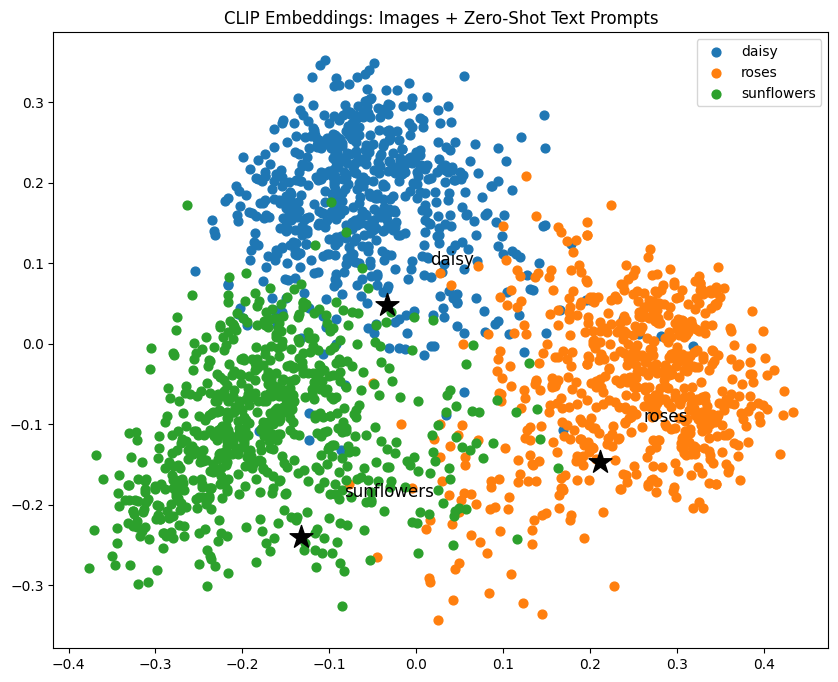

In [ ]:
plt.figure(figsize=(10, 8))

# Separate image and text embeddings in 2D space
image_emb_2d = emb_2d[:len(image_embeddings)]
text_emb_2d = emb_2d[len(image_embeddings):]

# Plot image points by class
for cls in kept_classes:
    # Use image_emb_2d for plotting image points
    class_points = image_emb_2d[np.array(labels) == cls]
    plt.scatter(class_points[:, 0], class_points[:, 1], label=cls, s=40)

# Plot text prompt embeddings
plt.scatter(text_emb_2d[:, 0], text_emb_2d[:, 1], s=300, marker='*', color='black')

# Label text embeddings
for i, cls in enumerate(kept_classes):
    x, y = text_emb_2d[i]
    plt.text(x+0.05, y+0.05, cls, fontsize=12) # Adjusted offset to +0.05

plt.title("CLIP Embeddings: Images + Zero-Shot Text Prompts")
plt.legend()
plt.show()

**10. Calculating the Zero-shot and per-class accuracies**

In [ ]:
image_t = torch.tensor(image_embeddings).to(device)
text_t = torch.tensor(text_embeddings).to(device)

similarity = image_t @ text_t.T
preds = similarity.argmax(dim=1).cpu().numpy()

correct = sum(kept_classes[p] == true for p, true in zip(preds, labels))
accuracy = correct / len(labels)

print(f"Zero-shot accuracy: {accuracy:.4f}")


Zero-shot accuracy: 0.9772


In [ ]:
from collections import defaultdict

correct_per_class = defaultdict(int)
total_per_class = defaultdict(int)

for pred, true_label in zip(preds, labels):
    total_per_class[true_label] += 1
    if kept_classes[pred] == true_label:
        correct_per_class[true_label] += 1

for cls in kept_classes:
    acc = correct_per_class[cls] / total_per_class[cls]
    print(f"{cls}: {acc:.4f}")


daisy: 0.9858
roses: 0.9579
sunflowers: 0.9871
